In [10]:
datadir = "/Users/chloelaforge/Desktop/SYS - Data"
csv_path = datadir + "/spam.csv"

import pandas as pd
df = pd.read_csv(csv_path, encoding='latin1')

df.head()



,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
spamonly = df[df['v1'] == 'spam']

num_duplicates = spamonly.duplicated().sum()

num_duplicates


np.int64(94)

In [12]:
spamonly_nodup = spamonly.drop_duplicates()

spamonly_nodup_count = len(spamonly_nodup)

spamonly_nodup_count


653

In [24]:
df_nodup = df.drop_duplicates().copy()

df_nodup["characters_count"] = df_nodup["v2"].str.len()

avg_length = round(df_nodup["characters_count"].mean(), 2)
avg_length



np.float64(79.19)

In [26]:
import re

df_nodup = df.drop_duplicates().copy()

df_nodup["sentences_count"] = df_nodup["v2"].apply(
    lambda x: len(re.findall(r'[.!?]', x)) if isinstance(x, str) else 0
)

max_sentences = df_nodup["sentences_count"].max()

max_sentences


np.int64(42)

In [16]:
df_nodup = df.drop_duplicates().copy()

df_nodup["words_count"] = df_nodup["v2"].apply(
    lambda x: len(str(x).split())
)

min_words = df_nodup["words_count"].min()

min_words


np.int64(1)

In [17]:
import re

df_nodup = df.drop_duplicates().copy()

first_five = df_nodup["v2"].head(5)

capital_counts = first_five.apply(lambda x: len(re.findall(r'[A-Z]', str(x))))

max_capitals = capital_counts.max()

max_capitals


np.int64(10)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 22.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 21.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 22.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


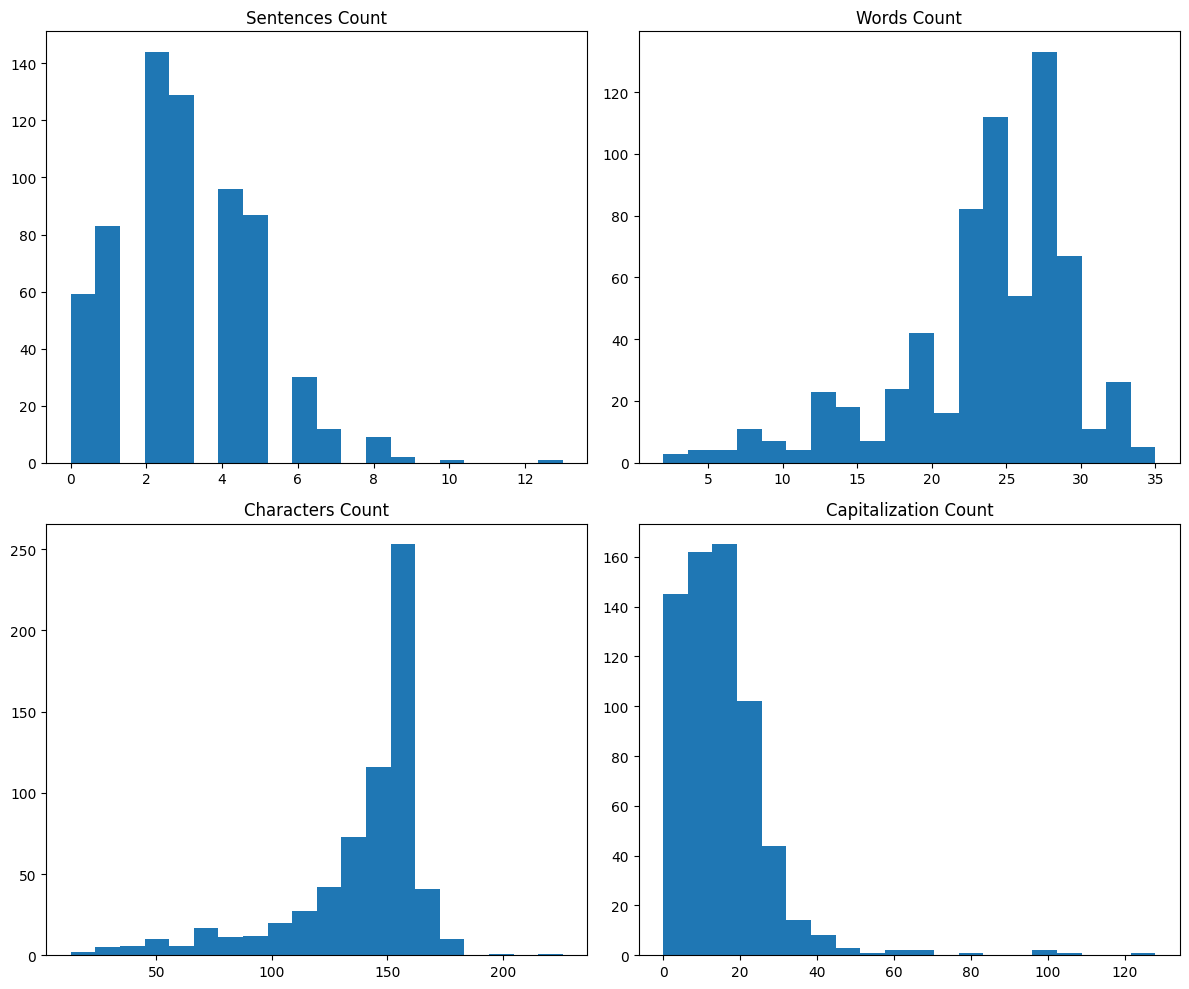

In [19]:
!pip3 install matplotlib

import matplotlib.pyplot as plt
import re

df_nodup = df.drop_duplicates().copy()

spam_df = df_nodup[df_nodup['v1'] == 'spam'].copy()


spam_df['sentences_count'] = spam_df['v2'].apply(
    lambda x: len(re.findall(r'[.!?]', str(x)))
)

spam_df['words_count'] = spam_df['v2'].apply(
    lambda x: len(str(x).split())
)

spam_df['characters_count'] = spam_df['v2'].apply(
    lambda x: len(str(x))
)

spam_df['capitalization_count'] = spam_df['v2'].apply(
    lambda x: len(re.findall(r'[A-Z]', str(x)))
)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(spam_df['sentences_count'], bins=20)
plt.title("Sentences Count")

plt.subplot(2, 2, 2)
plt.hist(spam_df['words_count'], bins=20)
plt.title("Words Count")

plt.subplot(2, 2, 3)
plt.hist(spam_df['characters_count'], bins=20)
plt.title("Characters Count")

plt.subplot(2, 2, 4)
plt.hist(spam_df['capitalization_count'], bins=20)
plt.title("Capitalization Count")

plt.tight_layout()
plt.show()


In [22]:
import re

# 1. Duplicate-free dataset
df_nodup = df.drop_duplicates().copy()

# 2. Encode target manually (no sklearn needed)
df_nodup["target_encoded"] = df_nodup["v1"].map({"ham": 0, "spam": 1})

# 3. Create feature columns
df_nodup["sentences_count"] = df_nodup["v2"].apply(
    lambda x: len(re.findall(r'[.!?]', str(x)))
)

df_nodup["words_count"] = df_nodup["v2"].apply(
    lambda x: len(str(x).split())
)

df_nodup["characters_count"] = df_nodup["v2"].apply(
    lambda x: len(str(x))
)

df_nodup["capitalization_count"] = df_nodup["v2"].apply(
    lambda x: len(re.findall(r'[A-Z]', str(x)))
)

# 4. Compute correlations with target_encoded
corr_matrix = df_nodup[[
    "target_encoded",
    "sentences_count",
    "words_count",
    "characters_count",
    "capitalization_count"
]].corr()

corr_with_target = corr_matrix["target_encoded"].sort_values(ascending=False)

corr_with_target


target_encoded          1.000000
characters_count        0.387922
capitalization_count    0.339780
words_count             0.286576
sentences_count         0.075214
Name: target_encoded, dtype: float64